# Project 1 - Exploratory Data Analysis on the Titanic dataset



In [48]:
# Import the main libraries used throughout the analysis.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [49]:
# Load the Titanic dataset from the same folder as this notebook.
df = pd.read_csv('titanic_dataset.csv')
print(f"Dataset shape: {df.shape}")


Dataset shape: (891, 12)


In [50]:
# A quick first look at the raw data. This helps check that the file loaded correctly and that the columns look sensible.
df.head(5)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [51]:
# Review the available columns and their inferred dtypes.
print("Columns:")
print(df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)


Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dtypes:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [66]:
# Basic summary statistics for the numeric columns.
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [75]:
# Check the number of non-null rows for each column and the distribution of null values.
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

print("Missing Counts:")
print(missing_count)
print("Missing %")
print(missing_pct)


Missing Counts:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Missing %
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


In [77]:
# Check for repeated rows.
duplicate_rows = df.duplicated()
print(f"Duplicate rows: {duplicate_rows.sum()}")


Duplicate rows: 0


In [79]:
# Check whether the ID column is unique. PassengerId is the natural candidate here.
duplicate_ids = df['PassengerId'].duplicated()
print(f"Duplicate PassengerId values: {duplicate_ids.sum()}")


Duplicate PassengerId values: 0


In [83]:
# Look for values that are clearly impossible or suspicious, without editing the data.
#Negative ages
neg_age = df[df['Age'] < 0] 
print(f"Rows with negative Age: {len(neg_age)}")


Rows with negative Age: 0


In [57]:
# Search for sentinel values that often appear in messy data.
# For this dataset, values like 0 are valid in some fields, so we treat them carefully rather than blindly flagging all zeroes.
sentinel_values = ['999', '-1', '?', 'N/A', 'NA']

for col in df.columns:
    series = df[col]
    if pd.api.types.is_numeric_dtype(series):
        suspicious = series[(series == 999) | (series == -1)]
        if not suspicious.empty:
            print(f"{col}: numeric sentinel values found -> {len(suspicious)}")
            print(suspicious.head().to_dict())
    else:
        text_like = series.astype(str).str.strip()
        suspicious = text_like[text_like.isin(sentinel_values)]
        if not suspicious.empty:
            print(f"{col}: text sentinel values found -> {len(suspicious)}")
            print(suspicious.head().to_dict())


In [58]:
# Check whether any column has a suspiciously small number of unique values, which can indicate a constant or near-constant field.
for col in df.columns:
    series = df[col].dropna()
    if series.empty:
        print(f"{col}: all values are missing")
    else:
        unique_count = series.nunique(dropna=True)
        unique_ratio = unique_count / len(series)
        if unique_count <= 1:
            print(f"{col}: constant column")
        elif unique_ratio < 0.02:
            print(f"{col}: near-constant column (unique ratio={unique_ratio:.4f}, unique_count={unique_count})")


Survived: near-constant column (unique ratio=0.0022, unique_count=2)
Pclass: near-constant column (unique ratio=0.0034, unique_count=3)
Sex: near-constant column (unique ratio=0.0022, unique_count=2)
SibSp: near-constant column (unique ratio=0.0079, unique_count=7)
Parch: near-constant column (unique ratio=0.0079, unique_count=7)
Embarked: near-constant column (unique ratio=0.0034, unique_count=3)


In [59]:
# Check the dtypes that were inferred when the data was read.
# This step is important because a number stored as text or a date stored as text can create false signal in EDA and modeling.
df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

## Target analysis

The target variable for this notebook is `Survived`. That is a sensible choice because it is the outcome a model would predict and it is directly relevant to the story in the Titanic data.

We will inspect its distribution, imbalance, and relationship with a small set of meaningful features.


Target column: Survived
count    891.000000
mean       0.383838
std        0.486592
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Survived, dtype: float64

Class balance (%):
Survived
0    61.62
1    38.38
Name: count, dtype: float64


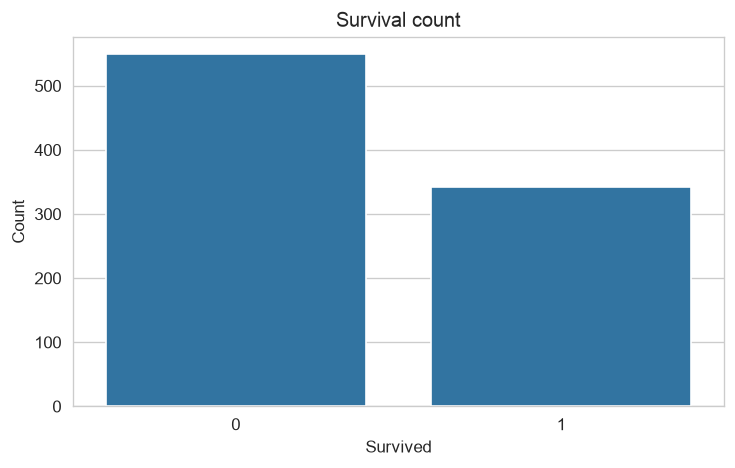

In [99]:
# Focus on the target variable and summarize its distribution.
target = 'Survived'

print(f"Target column: {target}")
print(df[target].describe())
print("\nClass balance (%):")
print((df[target].value_counts()/len(df[target]) * 100).round(2))

# Histogram for the target makes it clear whether the dataset is balanced or skewed.
fig, ax = plt.subplots(figsize = (7,4))
sns.countplot(data=df, x=target)
plt.title('Survival count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()


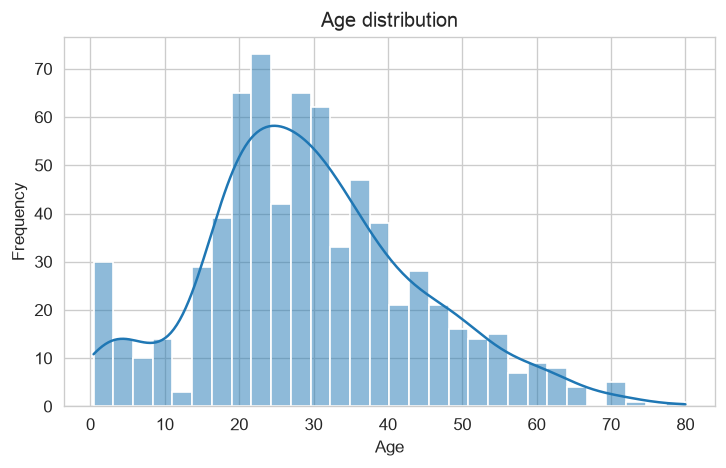

Age summary:
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64



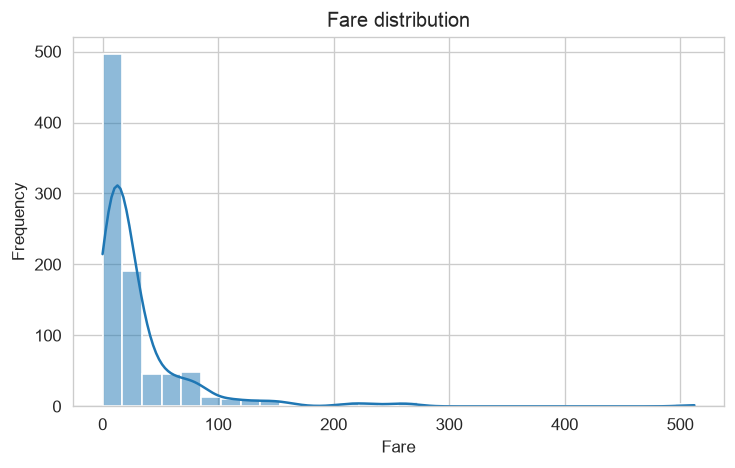

Fare summary:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64



In [101]:
# Inspect the distribution of age and fare, since these are central to the story.
for col in ['Age', 'Fare']:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        sns.histplot(df[col].dropna(), bins=30, kde= True)
        plt.title(f'{col} distribution')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()
        print(f"{col} summary:")
        print(df[col].describe())
        print()


## Findings and interpretation


The raw findings from this dataset are already clear: missingness is concentrated in Age and Cabin, the target is imbalanced, and the strongest relationship with survival is likely tied to passenger class and sex.


In [102]:
# Final verification check for the assignment requirements.

print('Notebook checks complete.')
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"Missing values total: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Target balance: {df['Survived'].value_counts(normalize=True).to_dict()}")



Notebook checks complete.
Rows: 891
Columns: 12
Missing values total: 866
Duplicate rows: 0
Target balance: {0: 0.6161616161616161, 1: 0.3838383838383838}


## Relationships (R4)

This section checks whether the target variable is related to likely predictors and whether the strongest statistical relationships are genuinely useful or are partly confounded by other variables.

The goal is to look for patterns that matter for later modeling, without claiming causation from a single exploratory view.


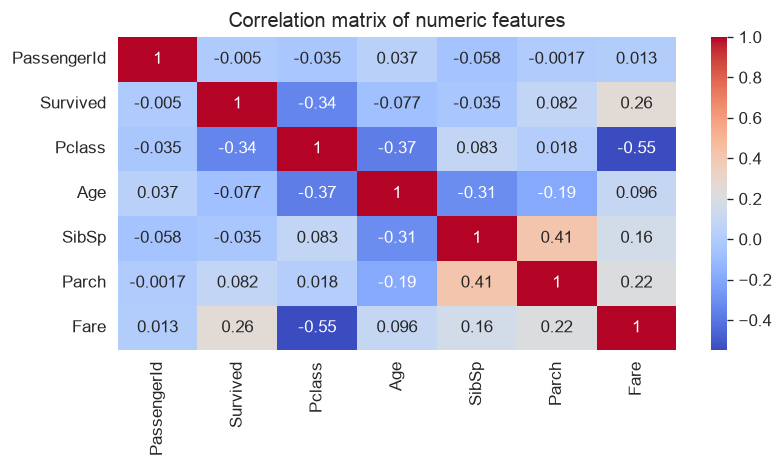

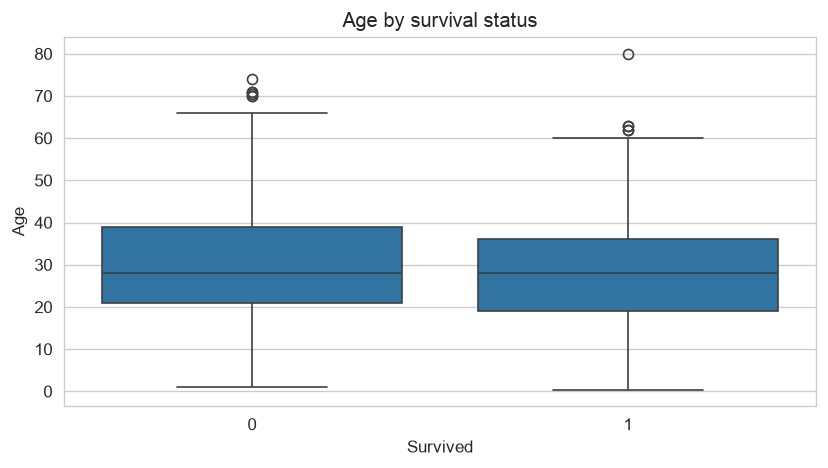

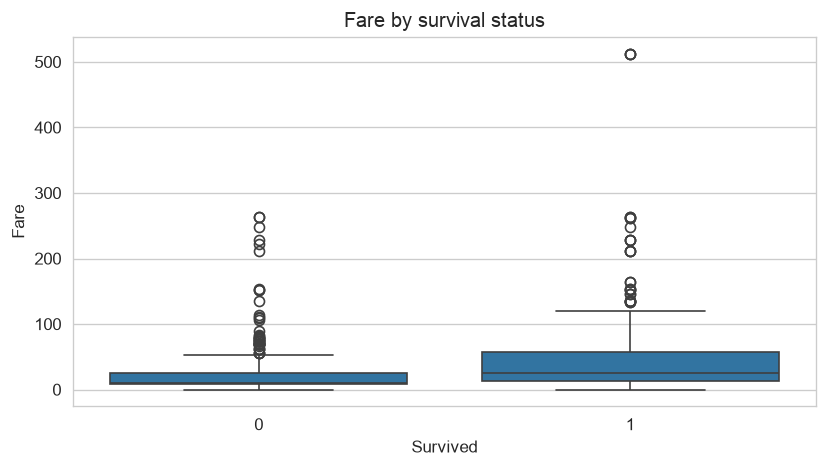

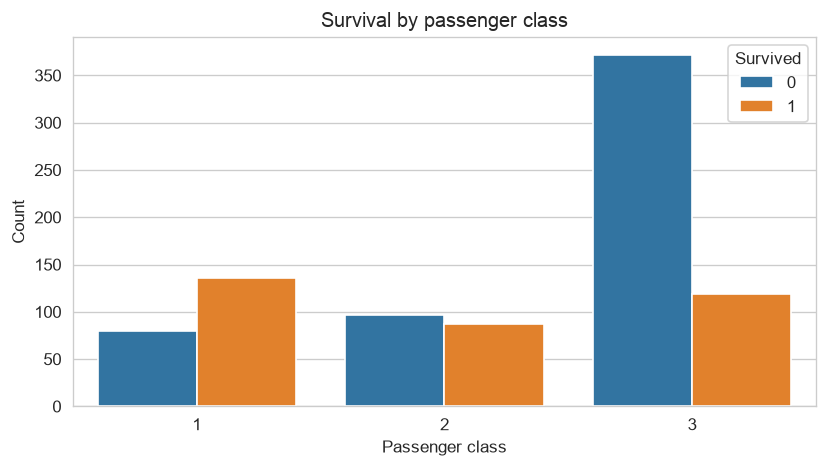

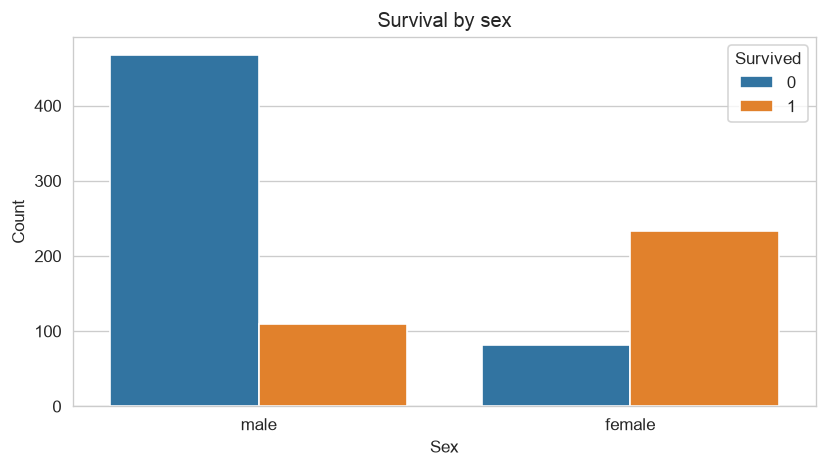

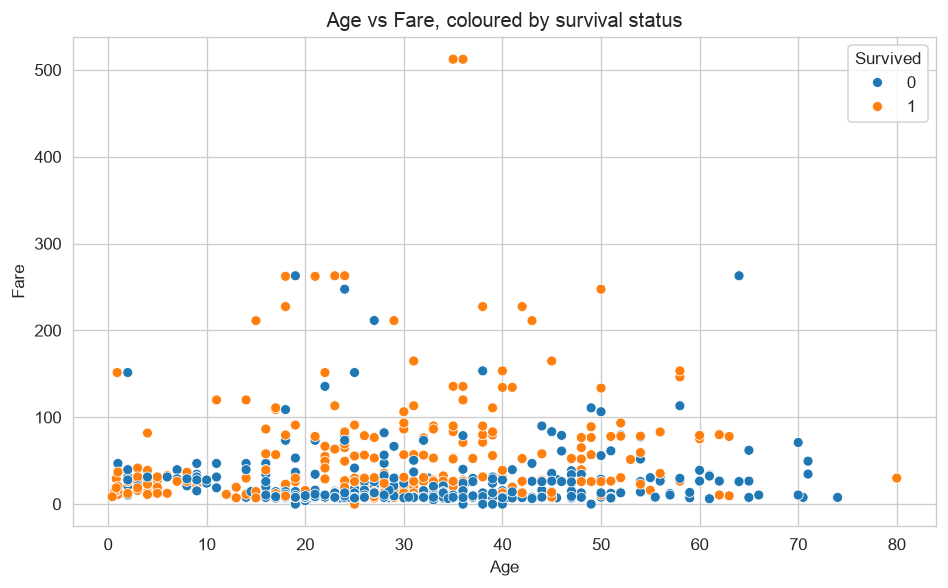

Numeric correlation matrix ready.
Relationships checked: Age, Fare, Pclass, Sex, and a scatter view of age vs fare.


In [108]:
# Relationship analysis for R4

# 1) Correlation matrix for numeric features
numeric_cols = df.select_dtypes(exclude = 'str').columns.tolist()
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation matrix of numeric features')
plt.tight_layout()
plt.tight_layout()
plt.show()

correlation_matrix

# 2) Survival vs age
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Survived', y='Age')
plt.title('Age by survival status')
plt.xlabel('Survived')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

# 3) Survival vs fare
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare by survival status')
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.tight_layout()
plt.show()

# 4) Survival vs passenger class
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival by passenger class')
plt.xlabel('Passenger class')
plt.ylabel('Count')
plt.legend(title='Survived')
plt.tight_layout()
plt.show()

# 5) Survival vs sex
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Survived')
plt.tight_layout()
plt.show()

# 6) One example of a misleading correlation check
# A variable may look weakly related in correlation but still have a meaningful pattern when viewed more closely.
# Here we show that a raw correlation can miss a non-linear relationship, so we do not over-interpret correlation alone.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived')
plt.title('Age vs Fare, coloured by survival status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.tight_layout()
plt.show()

# Quick evidence summary for the relationship section
print('Numeric correlation matrix ready.')
print('Relationships checked: Age, Fare, Pclass, Sex, and a scatter view of age vs fare.')
